Task 1 — Historical VaR & CVaR

In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

In [2]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [3]:
results = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    results.append({
        "amfi_code": code,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_df = pd.DataFrame(results)

var_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


Task 2 — Rolling 90 Day Sharpe

In [4]:
funds = nav["amfi_code"].unique()[:5]

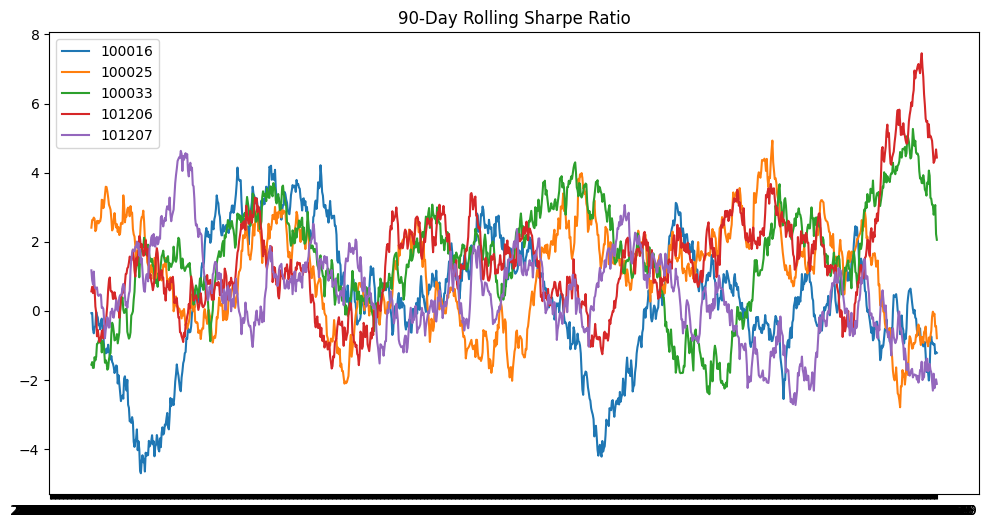

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for code in funds:

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    rolling_sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(code)
    )

plt.legend()
plt.title("90-Day Rolling Sharpe Ratio")

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

Task 3 — Investor Cohort Analysis

In [6]:
txn = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

In [7]:
first_txn = txn.groupby(
    "investor_id"
)["transaction_date"].min()

In [8]:
txn["cohort_year"] = txn[
    "investor_id"
].map(
    first_txn.dt.year
)

In [10]:
cohort = txn.groupby(
    "cohort_year"
).agg({
    "amount_inr":"mean"
})

cohort

,amount_inr
cohort_year,
2024,107422.541832
2025,109158.577061


Task 4 — SIP Continuity Analysis

In [11]:
sip = txn[
    txn["transaction_type"] == "SIP"
].copy()

In [12]:
sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

In [13]:
sip["gap_days"] = (
    sip.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

In [14]:
risk = sip.groupby(
    "investor_id"
)["gap_days"].mean()

at_risk = risk[
    risk > 35
]

print(
    "At Risk Investors:",
    len(at_risk)
)

At Risk Investors: 0


Task 6 — Sector HHI

In [15]:
portfolio = pd.read_csv(
    "../data/processed/portfolio_holdings_clean.csv"
)

In [16]:
portfolio["weight_sq"] = (
    portfolio["weight_pct"] / 100
) ** 2

In [18]:
hhi = portfolio.groupby(
    "amfi_code"
)["weight_sq"].sum()

hhi = hhi.reset_index()

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709
